### Correlação de potências - Olimpíadas e Paralimpíadas  

**A Pergunta:** Os países que dominam as Olimpíadas são os mesmos que dominam as Paralimpíadas?

In [163]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Primeiramente, lemos os CSVs com histórico de medalhas das Olimpíadas e Paralimpíadas

In [164]:
df_olimpiadas = pd.read_csv('olimpiadas_medalhas_arrumado.csv', encoding='utf-8')
display(df_olimpiadas.head())

df_paralimpiadas = pd.read_csv('paralimpiada_medalhas_arrumado.csv', encoding='utf-8')
display(df_paralimpiadas.head())

display(df_olimpiadas.info())
display(df_paralimpiadas.info())

,No.,País,Jogos,Ouro,Prata,Bronze,Total,NOC
0,1,Estados Unidos,29,1101,880,781,2762,USA
1,2,União Soviética,9,395,319,296,1010,URS
2,3,China,12,302,227,197,726,CHN
3,4,Grã-Bretanha,30,300,338,344,982,GBR
4,5,França,30,240,280,298,818,FRA


,País,Ouro,Prata,Bronze,Total,NOC
0,Estados Unidos,808,736,739,2283,USA
1,Grã-Bretanha,667,621,626,1914,GBR
2,Alemanha,521,529,500,1550,GER
3,China,535,400,302,1237,CHN
4,Austrália,389,422,394,1205,AUS


<class 'pandas.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   No.     155 non-null    int64
 1   País    155 non-null    str  
 2   Jogos   155 non-null    int64
 3   Ouro    155 non-null    int64
 4   Prata   155 non-null    int64
 5   Bronze  155 non-null    int64
 6   Total   155 non-null    int64
 7   NOC     154 non-null    str  
dtypes: int64(6), str(2)
memory usage: 9.8 KB


None

<class 'pandas.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   País    129 non-null    str  
 1   Ouro    129 non-null    int64
 2   Prata   129 non-null    int64
 3   Bronze  129 non-null    int64
 4   Total   129 non-null    int64
 5   NOC     129 non-null    str  
dtypes: int64(4), str(2)
memory usage: 6.2 KB


None

Aqui conferimos se há alguma inconsistência na coluna que representa o total de medalhas em relação às outras (medalhas de ouro, prata e bronze)

In [165]:
df_olimpiadas["Total_calc"] = df_olimpiadas['Ouro'] + df_olimpiadas['Prata'] + df_olimpiadas['Bronze']
inconsistente = df_olimpiadas[df_olimpiadas['Total'] != df_olimpiadas['Total_calc']]

print(inconsistente)

Empty DataFrame
Columns: [No., País, Jogos, Ouro, Prata, Bronze, Total, NOC, Total_calc]
Index: []


In [166]:
df_paralimpiadas["Total_calc"] = df_paralimpiadas['Ouro'] + df_paralimpiadas['Prata'] + df_paralimpiadas['Bronze']
inconsistente = df_paralimpiadas[df_paralimpiadas['Total'] != df_paralimpiadas['Total_calc']]

print(inconsistente) # Encontrou 17 inconsistências

                País  Ouro  Prata  Bronze  Total  NOC  Total_calc
6             Canadá   400    340     346   1080  CAN        1086
10            Itália   181    224     226    665  ITA         631
17     Coreia do Sul   128    126     121    365  KOR         375
22         Dinamarca    96     83     106    282  DEN         285
28         Argentina    31     66      69    165  ARG         166
31             Egito    49     52      63    150  EGY         164
33               RPC    36     33      49    116  RPC         118
35      Bielorrússia    41     35      31    106  BLR         107
37          Portugal    25     31      38    104  POR          94
38           Tunísia    43     39      22     94  TUN         104
48           Jamaica    21     16      18     54  JAM          55
55          Marrocos    16     11      11     39  MAR          38
63     Taipé Chinesa     5      6      14     23  TPE          25
75          Bulgária     5      9       3     15  BUL          17
81        

Consertamos as inconsistências substituindo o "Total" original pela soma correta e excluímos a coluna que foi criada durante a checagem

In [167]:
df_paralimpiadas["Total"] = df_paralimpiadas["Total_calc"]

inconsistente = df_paralimpiadas[df_paralimpiadas['Total'] != df_paralimpiadas['Total_calc']]

print(inconsistente)

Empty DataFrame
Columns: [País, Ouro, Prata, Bronze, Total, NOC, Total_calc]
Index: []


In [168]:
df_olimpiadas = df_olimpiadas.drop("Total_calc", axis=1)
df_paralimpiadas = df_paralimpiadas.drop("Total_calc", axis=1)

- *Plota um Gráfico de Barras dos 15 países com melhor desempenho nas Olimpíadas*

C:\Users\ednal\AppData\Local\Temp\ipykernel_14728\1151692400.py:5: UserWarning: 
The palette list has fewer values (1) than needed (15) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=df_top_olim, x='País', y='Total', hue= "País", palette=["#0c7ed0"], legend= False)


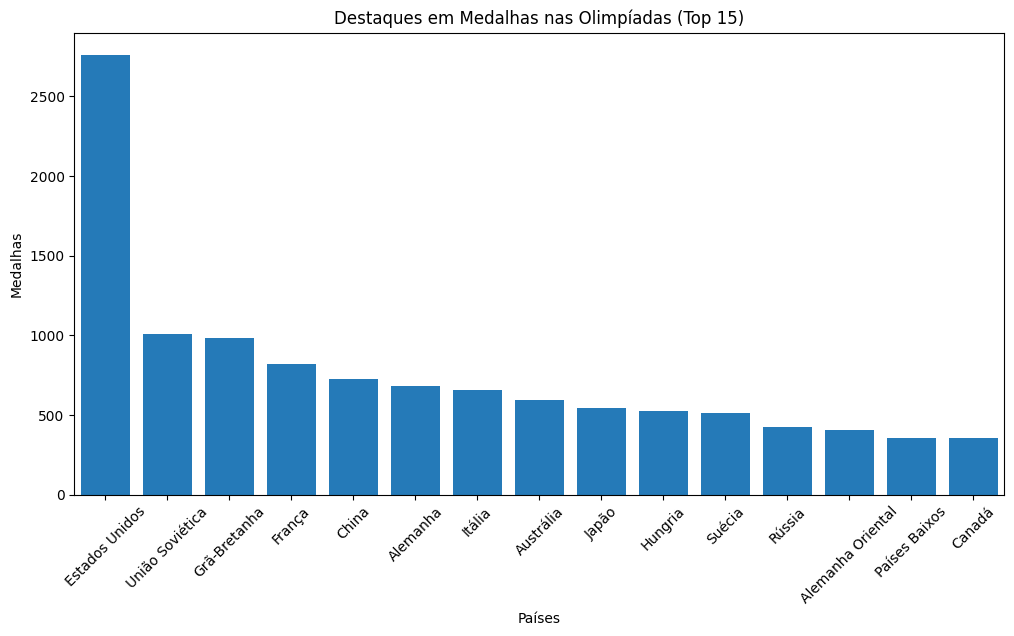

In [169]:
def potencias_olimpicas():
    df_top_olim = df_olimpiadas.nlargest(15, "Total")

    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_top_olim, x='País', y='Total', hue= "País", palette=["#0c7ed0"], legend= False)
    plt.xlabel("Países")
    plt.ylabel("Medalhas")
    plt.xticks(rotation=45)
    plt.title('Destaques em Medalhas nas Olimpíadas (Top 15)')
    plt.show()

potencias_olimpicas()

- *Plota um Gráfico de Barras dos 15 países com melhor desempenho nas Paralimpíadas*

C:\Users\ednal\AppData\Local\Temp\ipykernel_14728\1449674887.py:5: UserWarning: 
The palette list has fewer values (1) than needed (15) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=df_top_para, x='País', y='Total', hue= "País", palette=["#8ED1EB"], legend= False)


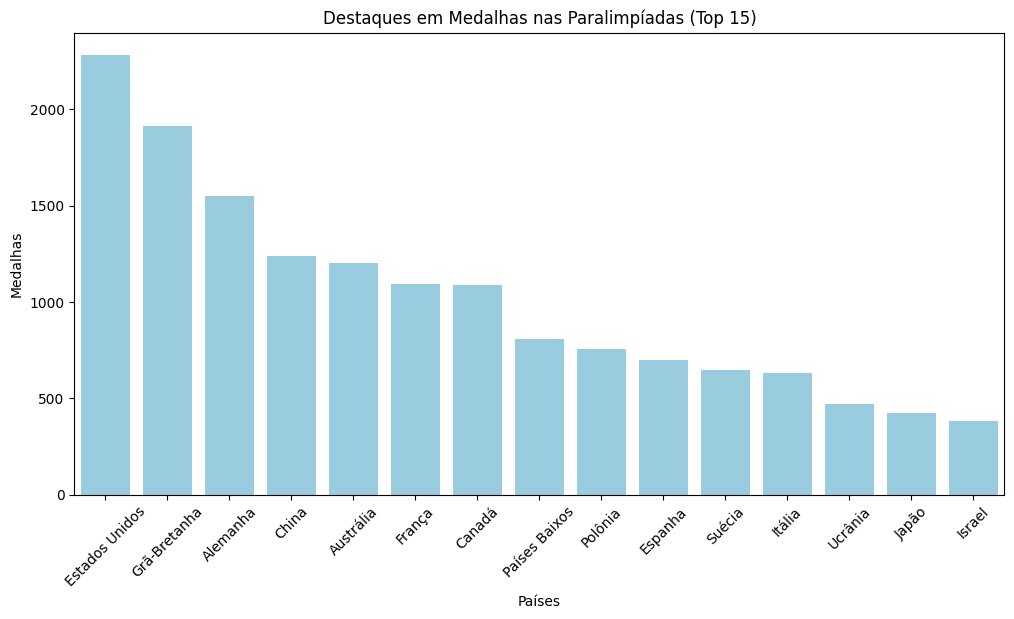

In [170]:
def potencias_paralimpicas():
    df_top_para = df_paralimpiadas.nlargest(15, "Total")

    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_top_para, x='País', y='Total', hue= "País", palette=["#8ED1EB"], legend= False)
    plt.xlabel("Países")
    plt.ylabel("Medalhas")
    plt.xticks(rotation=45)
    plt.title('Destaques em Medalhas nas Paralimpíadas (Top 15)')
    plt.show()

potencias_paralimpicas()

Criamos um novo dataframe que junta os dados do total de medalhas dos outros dois

In [171]:
df_olimpico_total = df_olimpiadas.sort_values(by= "Total", ascending= False)
df_olimpico_total = df_olimpico_total[['País', 'Total']]
df_olimpico_total = df_olimpico_total.rename(columns={"Total": "Total_Olimpico"})

df_paralimpico_total = df_paralimpiadas.sort_values(by= "Total", ascending= False)
df_paralimpico_total = df_paralimpico_total[['País', 'Total']]
df_paralimpico_total = df_paralimpico_total.rename(columns={"Total": "Total_Paralimpico"})

display(df_olimpico_total.head())
display(df_paralimpico_total.head())

,País,Total_Olimpico
0,Estados Unidos,2762
1,União Soviética,1010
3,Grã-Bretanha,982
4,França,818
2,China,726


,País,Total_Paralimpico
0,Estados Unidos,2283
1,Grã-Bretanha,1914
2,Alemanha,1550
3,China,1237
4,Austrália,1205


In [172]:
df_olim_e_para = pd.merge(df_olimpico_total, df_paralimpico_total, on='País', how='outer')
df_olim_e_para.fillna(0, inplace=True)
df_olim_e_para["Total_Combinado"] = df_olim_e_para["Total_Olimpico"] + df_olim_e_para["Total_Paralimpico"]
df_olim_e_para = df_olim_e_para[df_olim_e_para["Total_Combinado"] > 0]

display(df_olim_e_para.head())

,País,Total_Olimpico,Total_Paralimpico,Total_Combinado
0,Afeganistão,2.0,0.0,2.0
1,Alemanha,685.0,1550.0,2235.0
2,Alemanha Ocidental,204.0,0.0,204.0
3,Alemanha Oriental,409.0,0.0,409.0
4,Angola,0.0,8.0,8.0


Analisamos a correlação entre o total de medalhas dos dois eventos

In [173]:
df_olim_e_para[["Total_Olimpico", "Total_Paralimpico"]].corr() # É uma correlação positiva e bem forte

,Total_Olimpico,Total_Paralimpico
Total_Olimpico,1.000000,0.826106
Total_Paralimpico,0.826106,1.000000


- *Plota um Gráfico de Barras dos 15 países com melhor desempenho em total de medalhas geral*

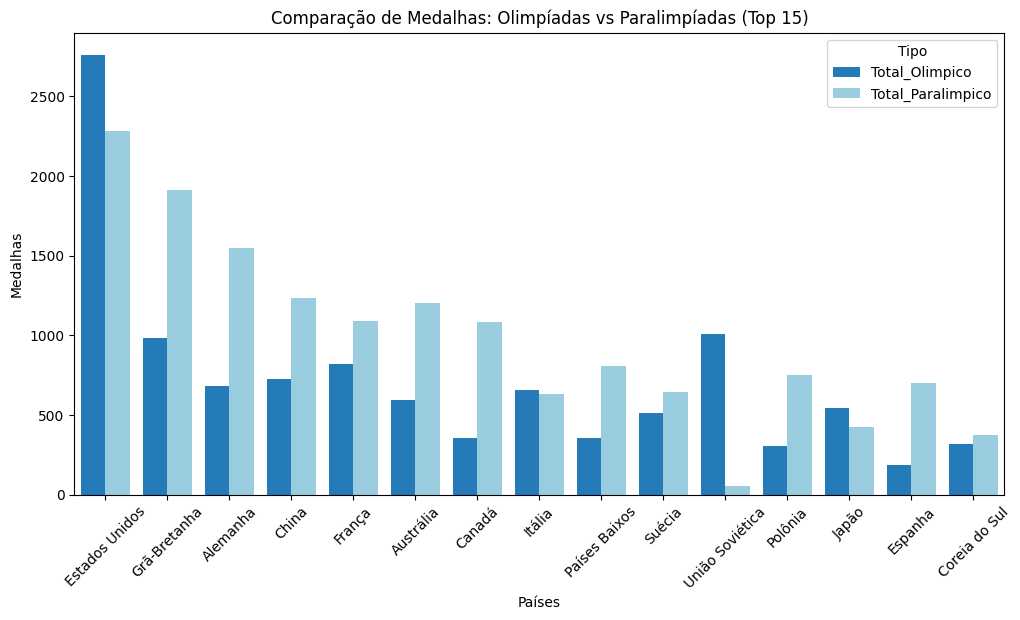

In [174]:
def compara_potencias():
    df_top = df_olim_e_para.nlargest(15, "Total_Combinado")
    df_plot = df_top.melt(id_vars='País', value_vars=['Total_Olimpico', 'Total_Paralimpico'], var_name='Tipo', value_name='Medalhas')

    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_plot, x='País', y='Medalhas', hue='Tipo',  palette=["#0c7ed0", "#8ED1EB"])
    plt.xlabel("Países")
    plt.ylabel("Medalhas")
    plt.xticks(rotation=45)
    plt.title('Comparação de Medalhas: Olimpíadas vs Paralimpíadas (Top 15)')
    plt.show()

compara_potencias()

- *Plota um Scatter Plot que compara o desempenho geral de todos os países*

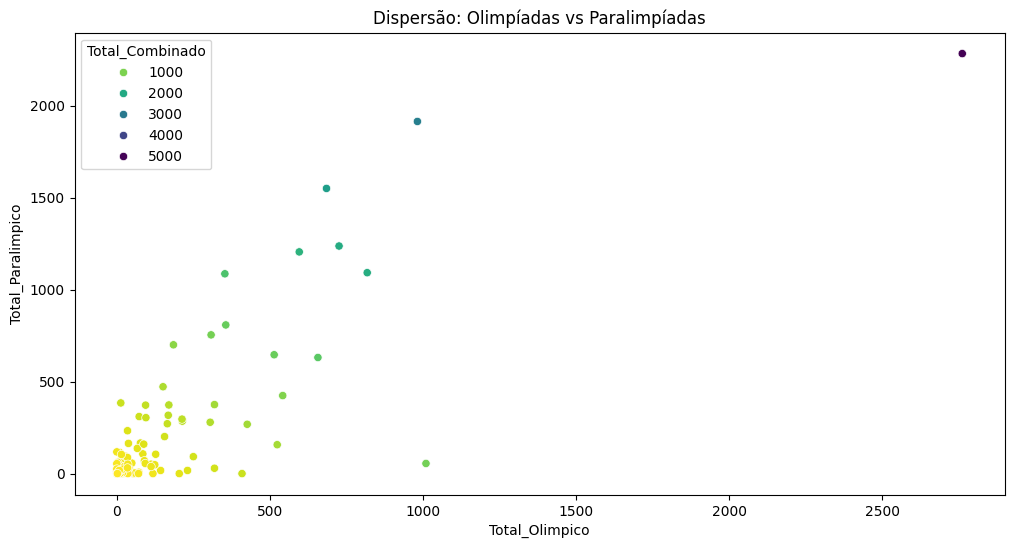

In [175]:
def scatter_plot():

    plt.figure(figsize=(12, 6))
    sns.scatterplot(data= df_olim_e_para, x= "Total_Olimpico", y= "Total_Paralimpico", hue= "Total_Combinado", palette= "viridis_r")
    plt.title('Dispersão: Olimpíadas vs Paralimpíadas')
    plt.show()

scatter_plot()

- *Plota o mesmo Scatter Plot sem os EUA (o principal outlier)*

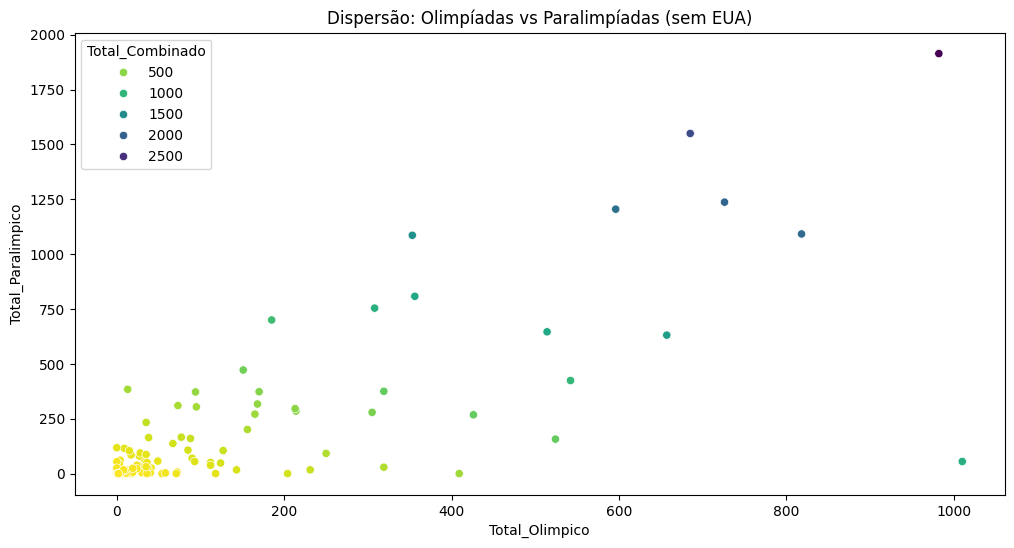

In [176]:
def scatter_plot_sem_eua():
    df_sem_eua = df_olim_e_para[df_olim_e_para["País"] != "Estados Unidos"]

    plt.figure(figsize=(12, 6))
    sns.scatterplot(data= df_sem_eua, x= "Total_Olimpico", y= "Total_Paralimpico", hue= "Total_Combinado", palette= "viridis_r")
    plt.title('Dispersão: Olimpíadas vs Paralimpíadas (sem EUA)')
    plt.show()

scatter_plot_sem_eua()

Aqui identificamos as "coordenadas" do Brasil para conseguir encontrá-lo em meio aos demais

In [177]:
df_olim_e_para[df_olim_e_para["País"] == "Brasil"]

,País,Total_Olimpico,Total_Paralimpico,Total_Combinado
22,Brasil,170.0,373.0,543.0


- *Plota um Scatter Plot que compara o desempenho geral de todos os países (com linha y = x) e Brasil destacado*

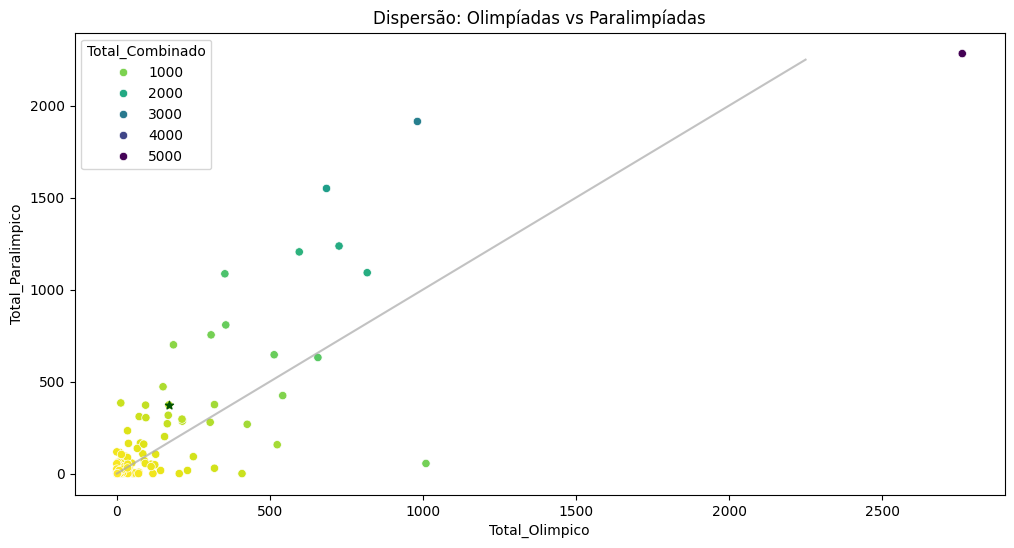

In [178]:
def plot_line_scale1():

    plt.figure(figsize=(12, 6))
    sns.scatterplot(data= df_olim_e_para, x= "Total_Olimpico", y= "Total_Paralimpico", hue= "Total_Combinado", palette= "viridis_r")
    plt.scatter(169, 373, marker = '*', color= "#015301")
    xpoints = np.array([0, 2250])
    ypoints = np.array([0, 2250])
    plt.plot(xpoints, ypoints, c= "#A9A9A9", alpha= 0.7)
    plt.title('Dispersão: Olimpíadas vs Paralimpíadas')
    plt.show()

plot_line_scale1()

- *Plota o Scatter Plot sem EUA (com linha y = x) e Brasil destacado*

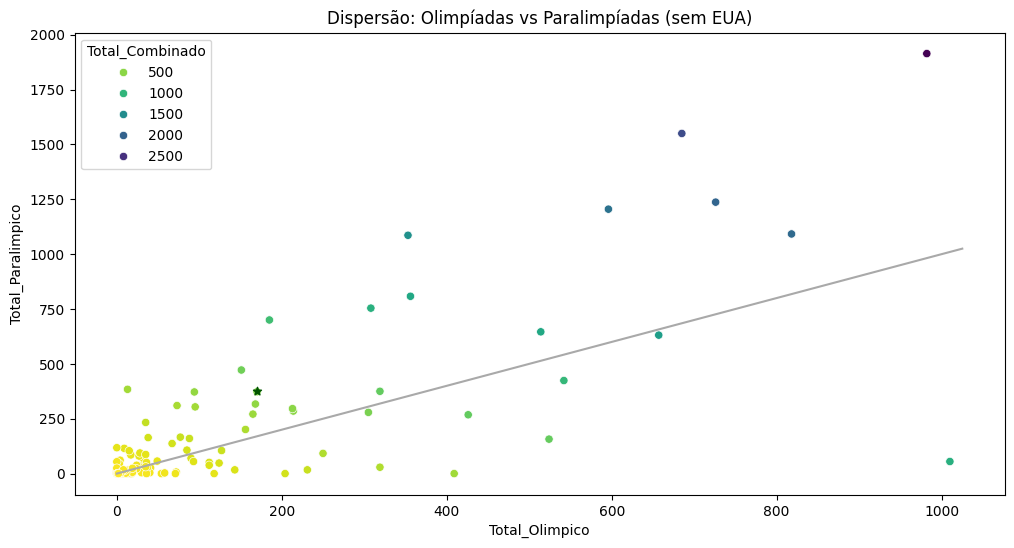

In [179]:
def plot_line_scale2():
    df_sem_eua = df_olim_e_para[df_olim_e_para["País"] != "Estados Unidos"]

    plt.figure(figsize=(12, 6))
    sns.scatterplot(data= df_sem_eua, x= "Total_Olimpico", y= "Total_Paralimpico", hue= "Total_Combinado", palette= "viridis_r")
    plt.scatter(169.5, 374.5, marker = '*', color= "#015301")
    xpoints = np.array([0, 1025])
    ypoints = np.array([0, 1025])
    plt.plot(xpoints, ypoints, c= "#A9A9A9")
    plt.title('Dispersão: Olimpíadas vs Paralimpíadas (sem EUA)')
    plt.show()

plot_line_scale2()

| **Top 15** | **Olimpíadas** | **Paralimpíadas** | **Total de Medalhas** |
| :---: | :---: | :---: | :---: |
| 1 | Estados Unidos | Estados Unidos | Estados Unidos |
| 2 | União Soviética | Grã-Bretanha | Grã-Bretanha |
| 3 | Grã-Bretanha | Alemanha | Alemanha |
| 4 | França | China | China |
| 5 | China | Austrália | França |
| 6 | Alemanha | França | Austrália |
| 7 | Itália | Canadá | Canadá |
| 8 | Austrália | Países Baixos | Itália |
| 9 | Japão | Polônia | Países Baixos |
| 10 | Hungria | Espanha | Suécia |
| 11 | Suécia | Suécia | União Soviética |
| 12 | Rússia | Itália | Polônia |
| 13 | Alemanha Oriental | Ucrânia | Japão |
| 14 | Países Baixos | Japão | Espanha |
| 15 | Canadá | Israel | Coreia do Sul |

**Quase todos os países que aparecem na tabela já sediaram ao menos um dos eventos, com exceção desses:**  

- Hungria
- Polônia
- Suécia
- Ucrânia

Por fim, fizemos uma análise mais específica da última edição de verão - Paris 2024

In [180]:
df_olim_2024 = pd.read_csv('csv\medalhas por ano olimpiadas\medalhas_paris_2024.csv', encoding='utf-8')
display(df_olim_2024.head())

df_para_2024 = pd.read_csv('csv\medalhas por ano paralimpiadas\paralimpicos_paris_2024.csv', encoding='utf-8')
display(df_para_2024.head())

<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
C:\Users\ednal\AppData\Local\Temp\ipykernel_14728\1099256023.py:1: SyntaxWarning: invalid escape sequence '\m'
  df_olim_2024 = pd.read_csv('csv\medalhas por ano olimpiadas\medalhas_paris_2024.csv', encoding='utf-8')
C:\Users\ednal\AppData\Local\Temp\ipykernel_14728\1099256023.py:4: SyntaxWarning: invalid escape sequence '\m'
  df_para_2024 = pd.read_csv('csv\medalhas por ano paralimpiadas\paralimpicos_paris_2024.csv', encoding='utf-8')


,Ordem,País,Ouro,Prata,Bronze,Total
0,1,USA Estados Unidos,40,44,42,126
1,2,CHN China,40,27,24,91
2,3,JPN Japão,20,12,13,45
3,4,AUS Austrália,18,19,16,53
4,5,FRA França,16,26,22,64


,Ordem,País,Ouro,Prata,Bronze,Total
0,1,CHN China,94,76,50,220
1,2,GBR Grã-Bretanha,49,44,31,124
2,3,USA Estados Unidos,36,42,27,105
3,4,NED Países Baixos,27,17,12,56
4,5,NPA Atletas Paralímpicos Neutros,26,22,23,71


In [181]:
df_olimpiadas_limpo = df_olim_2024['País'].str.extract(r'^([A-Z]{3})\s+(.*)')
df_olimpiadas_limpo.columns = ['NOC', 'País_Limpo']

df_olim_2024['NOC'] = df_olimpiadas_limpo['NOC']
df_olim_2024['País'] = df_olimpiadas_limpo['País_Limpo']

df_olim_2024['País'] = df_olim_2024['País'].str.replace(r'\[.*\]|\*', '', regex=True).str.strip()

display(df_olim_2024.head())

,Ordem,País,Ouro,Prata,Bronze,Total,NOC
0,1,Estados Unidos,40,44,42,126,USA
1,2,China,40,27,24,91,CHN
2,3,Japão,20,12,13,45,JPN
3,4,Austrália,18,19,16,53,AUS
4,5,França,16,26,22,64,FRA


In [182]:
df_paralimpiadas_limpo = df_para_2024['País'].str.extract(r'^([A-Z]{3})\s+(.*)')
df_paralimpiadas_limpo.columns = ['NOC', 'País_Limpo']

df_para_2024['NOC'] = df_paralimpiadas_limpo['NOC']
df_para_2024['País'] = df_paralimpiadas_limpo['País_Limpo']

df_para_2024['País'] = df_para_2024['País'].str.replace(r'\[.*\]|\*', '', regex=True).str.strip()

display(df_para_2024.head())

,Ordem,País,Ouro,Prata,Bronze,Total,NOC
0,1,China,94,76,50,220,CHN
1,2,Grã-Bretanha,49,44,31,124,GBR
2,3,Estados Unidos,36,42,27,105,USA
3,4,Países Baixos,27,17,12,56,NED
4,5,Atletas Paralímpicos Neutros,26,22,23,71,NPA


Fizemos a mesma checagem do total de medalhas

In [183]:
df_olim_2024["Total_calc"] = df_olim_2024['Ouro'] + df_olim_2024['Prata'] + df_olim_2024['Bronze']
inconsistente = df_olim_2024[df_olim_2024['Total'] != df_olim_2024['Total_calc']]

print(inconsistente)

Empty DataFrame
Columns: [Ordem, País, Ouro, Prata, Bronze, Total, NOC, Total_calc]
Index: []


In [184]:
df_para_2024["Total_calc"] = df_para_2024['Ouro'] + df_para_2024['Prata'] + df_para_2024['Bronze']
inconsistente = df_para_2024[df_para_2024['Total'] != df_para_2024['Total_calc']]

print(inconsistente)

Empty DataFrame
Columns: [Ordem, País, Ouro, Prata, Bronze, Total, NOC, Total_calc]
Index: []


In [185]:
df_olim_2024 = df_olim_2024.drop("Total_calc", axis=1)
df_para_2024 = df_para_2024.drop("Total_calc", axis=1)

- *Plota um Gráfico de Barras dos 15 melhores países nas Olimpíadas 2024*

C:\Users\ednal\AppData\Local\Temp\ipykernel_14728\3275233784.py:5: UserWarning: 
The palette list has fewer values (1) than needed (15) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=df_top_olim, x='País', y='Total', hue= "País", palette=["#0c7ed0"], legend= False)


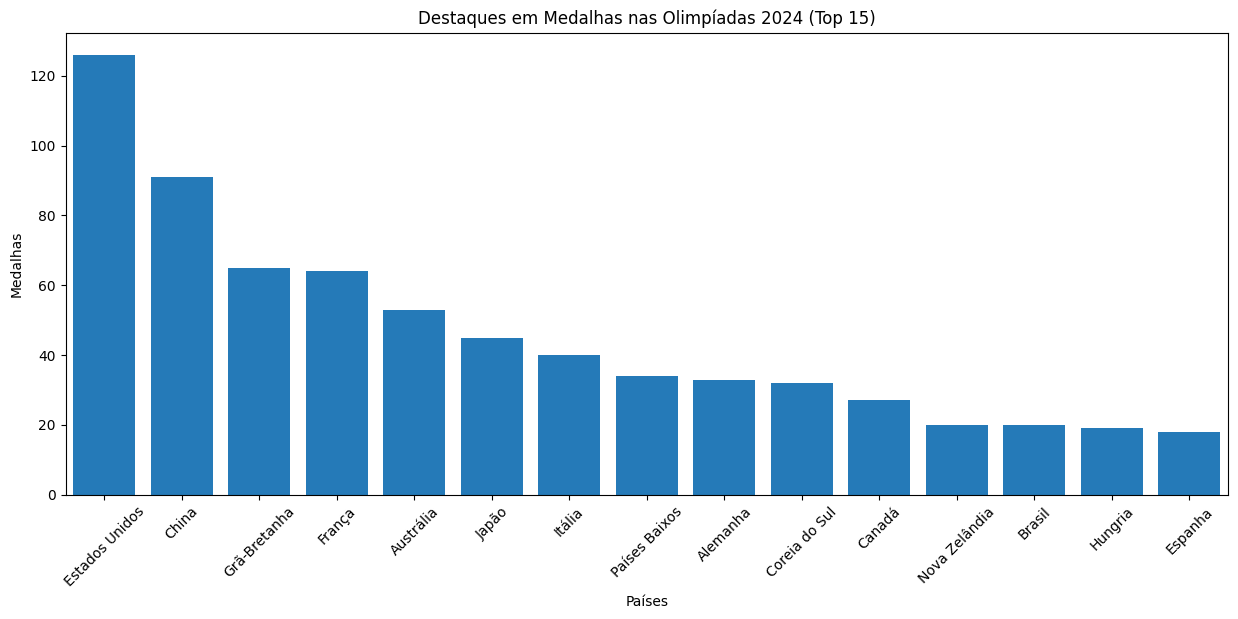

In [186]:
def potencias_olimpicas_24():
    df_top_olim = df_olim_2024.nlargest(15, "Total")

    plt.figure(figsize=(15, 6))
    sns.barplot(data=df_top_olim, x='País', y='Total', hue= "País", palette=["#0c7ed0"], legend= False)
    plt.xlabel("Países")
    plt.ylabel("Medalhas")
    plt.xticks(rotation=45)
    plt.title('Destaques em Medalhas nas Olimpíadas 2024 (Top 15)')
    plt.show()

potencias_olimpicas_24()

- *Plota um Gráfico de Barras dos 15 melhores países nas Paralimpíadas 2024*

C:\Users\ednal\AppData\Local\Temp\ipykernel_14728\3510786841.py:5: UserWarning: 
The palette list has fewer values (1) than needed (15) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=df_top_para, x='País', y='Total', hue= "País", palette=["#8ED1EB"], legend= False)


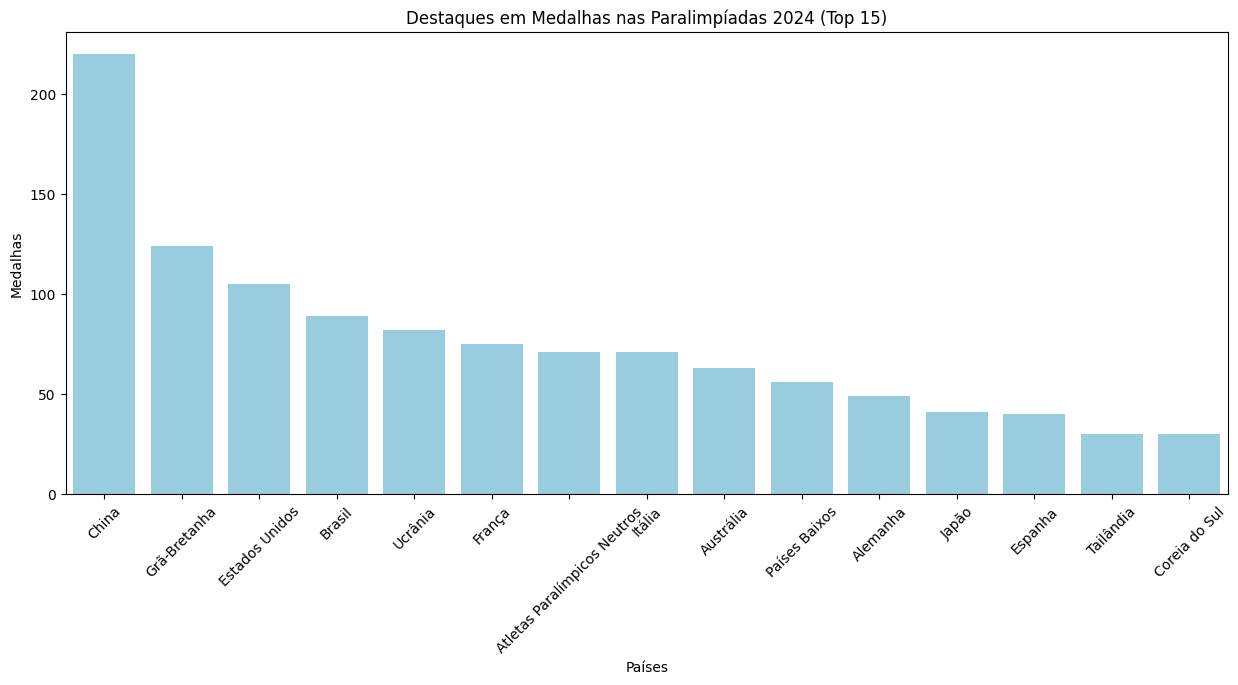

In [187]:
def potencias_paralimpicas_24():
    df_top_para = df_para_2024.nlargest(15, "Total")

    plt.figure(figsize=(15, 6))
    sns.barplot(data=df_top_para, x='País', y='Total', hue= "País", palette=["#8ED1EB"], legend= False)
    plt.xlabel("Países")
    plt.ylabel("Medalhas")
    plt.xticks(rotation=45)
    plt.title('Destaques em Medalhas nas Paralimpíadas 2024 (Top 15)')
    plt.show()

potencias_paralimpicas_24()

In [188]:
df_olimpico_total_24 = df_olim_2024.sort_values(by= "Total", ascending= False)
df_olimpico_total_24 = df_olimpico_total_24[['País', 'Total']]
df_olimpico_total_24 = df_olimpico_total_24.rename(columns={"Total": "Total_Olimpico"})

df_paralimpico_total_24 = df_para_2024.sort_values(by= "Total", ascending= False)
df_paralimpico_total_24 = df_paralimpico_total_24[['País', 'Total']]
df_paralimpico_total_24 = df_paralimpico_total_24.rename(columns={"Total": "Total_Paralimpico"})

display(df_olimpico_total_24.head())
display(df_paralimpico_total_24.head())

,País,Total_Olimpico
0,Estados Unidos,126
1,China,91
6,Grã-Bretanha,65
4,França,64
3,Austrália,53


,País,Total_Paralimpico
0,China,220
1,Grã-Bretanha,124
2,Estados Unidos,105
5,Brasil,89
7,Ucrânia,82


In [189]:
df_olim_e_para_2024 = pd.merge(df_olimpico_total_24, df_paralimpico_total_24, on='País', how='outer')
df_olim_e_para_2024.fillna(0, inplace=True)
df_olim_e_para_2024["Total_Combinado"] = df_olim_e_para_2024["Total_Olimpico"] + df_olim_e_para_2024["Total_Paralimpico"]
df_olim_e_para_2024 = df_olim_e_para_2024[df_olim_e_para_2024["Total_Combinado"] > 0]

display(df_olim_e_para_2024.head())

,País,Total_Olimpico,Total_Paralimpico,Total_Combinado
0,Albânia,2.0,0.0,2.0
1,Alemanha,33.0,49.0,82.0
2,Argentina,3.0,13.0,16.0
3,Argélia,3.0,11.0,14.0
4,Armênia,4.0,0.0,4.0


- *Plota um Gráfico de Barras dos 15 melhores países em 2024*

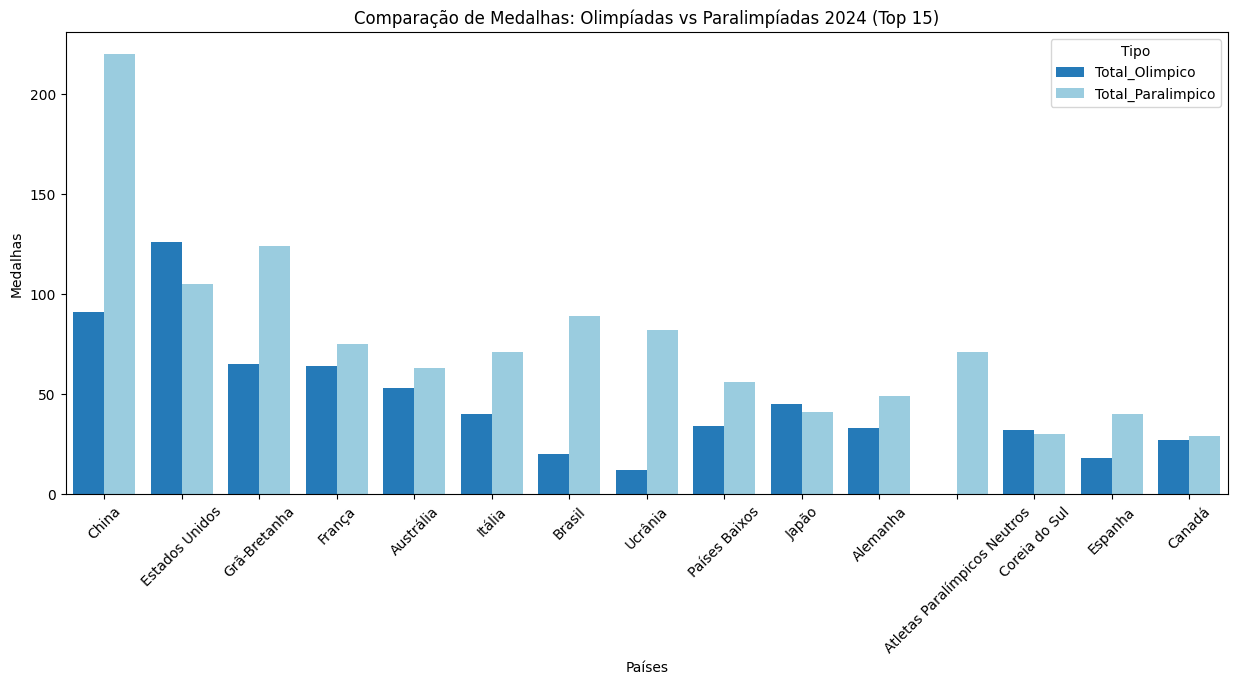

In [190]:
def compara_potencias_24():
    df_top = df_olim_e_para_2024.nlargest(15, "Total_Combinado")
    df_plot = df_top.melt(id_vars='País', value_vars=['Total_Olimpico', 'Total_Paralimpico'], var_name='Tipo', value_name='Medalhas')

    plt.figure(figsize=(15, 6))
    sns.barplot(data=df_plot, x='País', y='Medalhas', hue='Tipo',  palette=["#0c7ed0", "#8ED1EB"])
    plt.xlabel("Países")
    plt.ylabel("Medalhas")
    plt.xticks(rotation=45)
    plt.title('Comparação de Medalhas: Olimpíadas vs Paralimpíadas 2024 (Top 15)')
    plt.show()

compara_potencias_24()

- *Plota um Scatter Plot que compara o desempenho geral dos países em 2024*

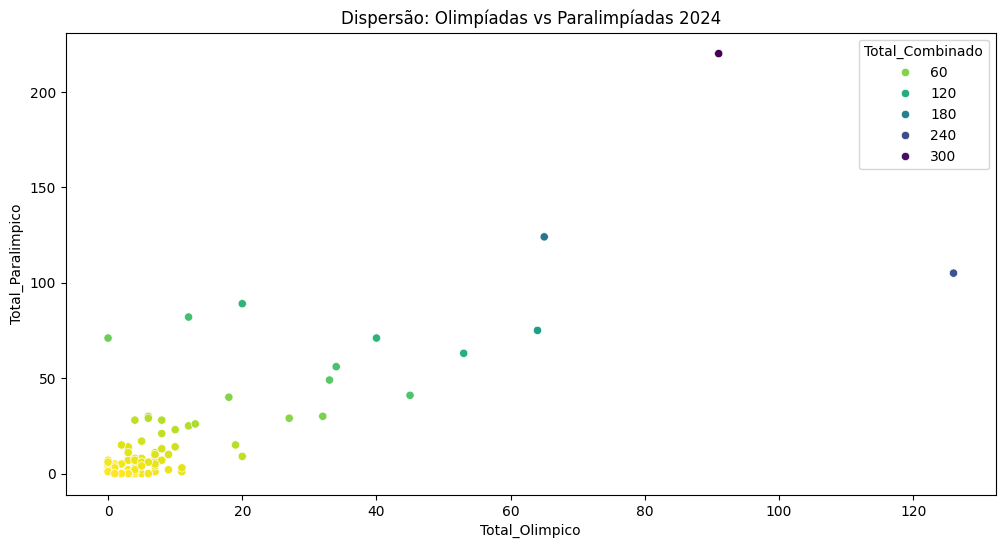

In [191]:
def scatter_plot_24():

    plt.figure(figsize=(12, 6))
    sns.scatterplot(data= df_olim_e_para_2024, x= "Total_Olimpico", y= "Total_Paralimpico", hue= "Total_Combinado", palette= "viridis_r")
    plt.title('Dispersão: Olimpíadas vs Paralimpíadas 2024')
    plt.show()

scatter_plot_24()

In [192]:
df_olim_e_para_2024[df_olim_e_para_2024["País"] == "Brasil"]

,País,Total_Olimpico,Total_Paralimpico,Total_Combinado
12,Brasil,20.0,89.0,109.0


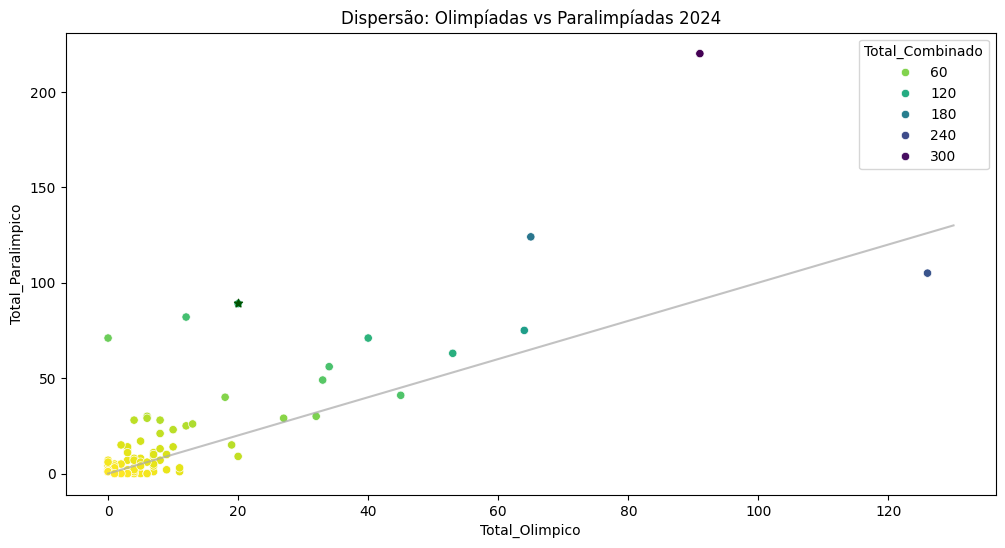

In [193]:
def plot_line_24():

    plt.figure(figsize=(12, 6))
    sns.scatterplot(data= df_olim_e_para_2024, x= "Total_Olimpico", y= "Total_Paralimpico", hue= "Total_Combinado", palette= "viridis_r")
    plt.scatter(20, 89.5, marker = '*', color= "#015301")
    xpoints = np.array([0, 130])
    ypoints = np.array([0, 130])
    plt.plot(xpoints, ypoints, c= "#A9A9A9", alpha= 0.7)
    plt.title('Dispersão: Olimpíadas vs Paralimpíadas 2024')
    plt.show()

plot_line_24()

#### Conclusão:

De um modo geral, sim. Ao analisar os países que mais se destacam em cada um dos eventos, a maioria dos nomes se repete, sendo estes os que apresentam melhor desempenho geral. A correlação positiva e os gráficos também nos mostram que em geral, o número de medalhas em cada evento cresce junto. Porém, ao comparar em números esse desempenho, é interessante observar que a maioria desses países (e também grande parte dos demais) possui melhores resultados nas Paralimpíadas, a exemplo do próprio Brasil.  
A estrutura das Paralimpíadas quanto à divisão das provas em categorias funcionais (depende da deficiência) abre mais espaço para atletas multi-medalhistas. Além disso, alguns países realmente investem mais nas Paralimpíadas, e isso tudo contribui para os resultados que vemos.